# PPLM Latent Dataset Construction

This notebook constructs the latent-representation dataset used to train the
PPLM CEFR attribute classifier. Texts from the Steering Training Dataset are
passed through the frozen Llama-3.1-8B-Instruct backbone, and mean-pooled
hidden representations are extracted from the selected hidden layer. The
resulting EFCAMDAT representations are then combined with the existing
CEFR latent-representation dataset and published to Hugging Face.

In [ ]:
!pip install -q transformers datasets huggingface_hub accelerate torch pandas

In [ ]:
import torch
import os
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset, Dataset, concatenate_datasets
from huggingface_hub import login
from tqdm import tqdm
from google.colab import drive

In [ ]:
# =========================================================
# 1. AUTHENTICATION & CONFIGURATION
# =========================================================
hf_token = "HF_Token"
login(token=hf_token)

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')


Mounting Google Drive...
Mounted at /content/drive


In [ ]:
# Paths
input_csv_path = "/content/drive/MyDrive/Your_Path/efcamdat_classifier_subset.csv"

# Target Repositories
previous_repo_id = "MohammadKhosravi/cefr-llama3.1-8b-hidden-states-combined"
new_repo_id = "MohammadKhosravi/cefr-llama3.1-8b-hidden-states-efcamdat-universal"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# =========================================================
# 2. LOAD EFCAMDAT SUBSET
# =========================================================
print("\nLoading EFCAMDAT Classifier Subset from Google Drive...")
df = pd.read_csv(input_csv_path)

# Drop text_id and level as agreed. Rename columns to match HF format.
df = df[['clean_text', 'cefr']].rename(columns={'clean_text': 'text', 'cefr': 'cefr_level'})
new_dataset = Dataset.from_pandas(df)

print(f"Successfully loaded {len(new_dataset)} EFCAMDAT rows for extraction.")


Loading EFCAMDAT Classifier Subset from Google Drive...
Successfully loaded 52657 EFCAMDAT rows for extraction.


In [ ]:
# =========================================================
# 3. LOAD LLAMA-3.1-8B-INSTRUCT
# =========================================================
model_id = "meta-llama/Llama-3.1-8B-Instruct"
print("\nLoading Tokenizer and Model...")

tokenizer = AutoTokenizer.from_pretrained(model_id, token=hf_token)
tokenizer.pad_token = tokenizer.eos_token
# Padding side doesn't technically matter for Mean Pooling, but right is standard
tokenizer.padding_side = "right"

# Load in bfloat16 for optimal A100 performance
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=hf_token
)
model.eval()


Loading Tokenizer and Model...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
  

In [ ]:
# =========================================================
# 4. EXTRACTION SETUP & CHECKPOINTING
# =========================================================
checkpoint_file = "efcamdat_llama3_vectors_checkpoint.pt"

if os.path.exists(checkpoint_file):
    print("\nFound existing checkpoint. Resuming extraction...")
    saved_data = torch.load(checkpoint_file)
    all_vectors = saved_data["vectors"]
    all_labels = saved_data["labels"]
    start_idx = len(all_labels)
    print(f"Resuming from row {start_idx}")
else:
    print("\nNo checkpoint found. Starting extraction from scratch.")
    all_vectors = []
    all_labels = []
    start_idx = 0

# If using A100, batch_size=32 is great. If using T4, drop this back to 8.
batch_size = 32
save_every = 500

# Target Layer -2 (Penultimate layer captures high-level syntactic/stylistic traits perfectly)
target_layer_idx = -2


No checkpoint found. Starting extraction from scratch.


In [ ]:
# =========================================================
# 5. BATCHED EXTRACTION LOOP
# =========================================================
pbar = tqdm(total=len(new_dataset), initial=start_idx, desc="Extracting EFCAMDAT Vectors")

for i in range(start_idx, len(new_dataset), batch_size):
    batch = new_dataset[i : i + batch_size]
    texts = batch["text"]
    labels = batch["cefr_level"]

    # Max length truncation protects against OOM errors from unusually long essays
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=1024, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

        target_hidden = outputs.hidden_states[target_layer_idx]

        # Mean Pooling with Attention Mask
        attention_mask = inputs.attention_mask.unsqueeze(-1) # Shape: (batch_size, seq_len, 1)

        # Eliminate padding elements from mathematical calculation paths
        sum_hidden = torch.sum(target_hidden * attention_mask, dim=1)
        valid_tokens = torch.clamp(attention_mask.sum(dim=1), min=1e-9)
        mean_vectors = sum_hidden / valid_tokens # Shape: (batch_size, 4096)

    # Immediately push vectors to host memory to protect VRAM banks
    all_vectors.extend(mean_vectors.cpu().to(torch.float32).tolist())
    all_labels.extend(labels)

    pbar.update(len(texts))

    # Save Checkpoint
    if len(all_labels) % save_every < batch_size:
        torch.save({"vectors": all_vectors, "labels": all_labels}, checkpoint_file)

pbar.close()

# Final safety save
torch.save({"vectors": all_vectors, "labels": all_labels}, checkpoint_file)
print("✅ Extraction complete and saved locally.")

# Free up GPU Memory
del model
torch.cuda.empty_cache()


Extracting EFCAMDAT Vectors: 100%|██████████| 52657/52657 [34:34<00:00, 25.38it/s]


✅ Extraction complete and saved locally.


In [ ]:
# =========================================================
# 6. MERGE WITH EXISTING HUGGING FACE DATASET
# =========================================================
print("\nPreparing extracted EFCAMDAT dataset for fusion...")
efcamdat_vector_dataset = Dataset.from_dict({
    "hidden_vector": all_vectors,
    "cefr_level": all_labels
})

print(f"Downloading previous Universal CEFR dataset from: {previous_repo_id}")
universal_hf_dataset = load_dataset(previous_repo_id, split="train")

print("Merging the datasets...")
final_combined_dataset = concatenate_datasets([universal_hf_dataset, efcamdat_vector_dataset])

print("Shuffling the final merged dataset...")
final_combined_dataset = final_combined_dataset.shuffle(seed=42)

print(f"Fusion successful! Final Unified Dataset Rows: {len(final_combined_dataset)}")


Preparing extracted EFCAMDAT dataset for fusion...


README.md:   0%|          | 0.00/4.48k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/13837 [00:00<?, ? examples/s]

Merging the datasets...
Shuffling the final merged dataset...
Fusion successful! Final Unified Dataset Rows: 66494


In [ ]:
# =========================================================
# 7. PUSH TO NEW HUGGING FACE REPOSITORY
# =========================================================
print(f"\nPushing final unified dataset to NEW repository: {new_repo_id}...")

final_combined_dataset.push_to_hub(new_repo_id, private=False)

print("\n🎉 SUCCESS! Unified EFCAMDAT + Universal CEFR hidden states dataset is live on Hugging Face!")
print(f"Link: https://huggingface.co/datasets/{new_repo_id}")


Pushing final unified dataset to NEW repository: MohammadKhosravi/cefr-llama3.1-8b-hidden-states-efcamdat-universal...


Uploading the dataset shards:   0%|          | 0/5 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/14 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Creating parquet from Arrow format:   0%|          | 0/14 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   0%|          |  534kB /  241MB            


🎉 SUCCESS! Unified EFCAMDAT + Universal CEFR hidden states dataset is live on Hugging Face!
Link: https://huggingface.co/datasets/MohammadKhosravi/cefr-llama3.1-8b-hidden-states-efcamdat-universal


# The Final Dataset Distribution

README.md:   0%|          | 0.00/336 [00:00<?, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/241M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/241M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/241M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/242M [00:00<?, ?B/s]

data/train-00004-of-00005.parquet:   0%|          | 0.00/241M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/66494 [00:00<?, ? examples/s]


 📈 FINAL UNIFIED TRAINING DATASET SUMMARY
Level A1:   15,003 vectors | Allocation: 22.56%
Level A2:   15,002 vectors | Allocation: 22.56%
Level B1:   15,049 vectors | Allocation: 22.63%
Level B2:   15,010 vectors | Allocation: 22.57%
Level C1:    5,013 vectors | Allocation: 7.54%
Level C2:    1,303 vectors | Allocation: 1.96%
--------------------------------------------------
Total Combined Training Manifold Volume: 66,494 samples

Generating dataset distribution chart...


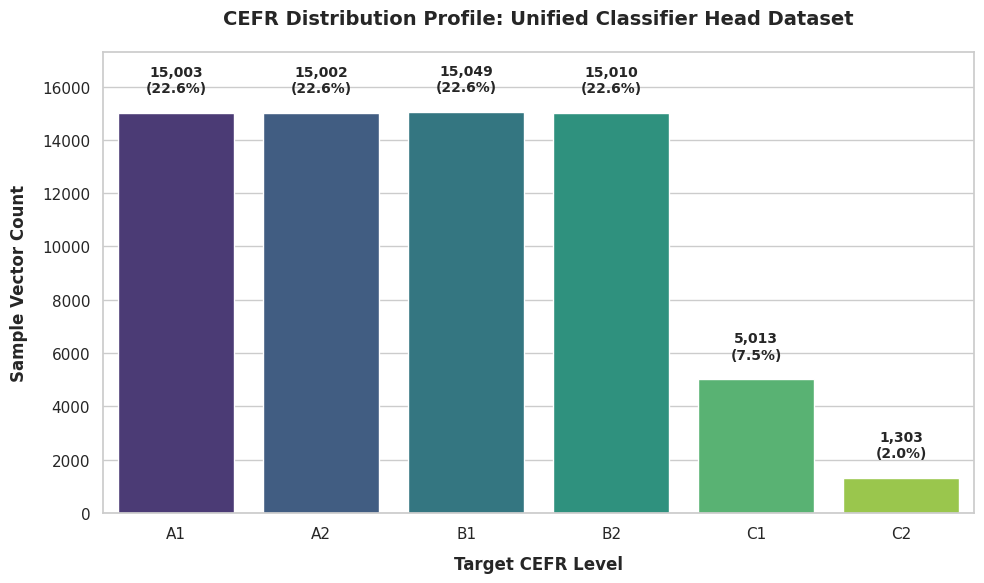

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datasets import load_dataset
from huggingface_hub import login

# =========================================================
# 1. AUTHENTICATION & LOADING
# =========================================================
hf_token = "HF_Token"
login(token=hf_token)

repo_id = "MohammadKhosravi/cefr-llama3.1-8b-hidden-states-efcamdat-universal"

print(f"Downloading unified vector dataset from Hugging Face: {repo_id}...")
# Loading with split='train' pulls it directly down as a Dataset object
dataset = load_dataset(repo_id, split="train")

# Convert metadata to a lightweight Pandas DataFrame for fast aggregation
df_stats = pd.DataFrame({"cefr_level": dataset["cefr_level"]})

# =========================================================
# 2. STATISTICAL CALCULATIONS
# =========================================================
total_samples = len(df_stats)
cefr_order = ["A1", "A2", "B1", "B2", "C1", "C2"]

# Calculate exact value frequencies mapped to our strict CEFR order
counts = df_stats["cefr_level"].value_counts().reindex(cefr_order, fill_value=0)

print("\n==================================================")
print(" 📈 FINAL UNIFIED TRAINING DATASET SUMMARY")
print("==================================================")
for level in cefr_order:
    count = counts[level]
    percentage = (count / total_samples) * 100
    print(f"Level {level}: {count:>8,} vectors | Allocation: {percentage:.2f}%")

print("--------------------------------------------------")
print(f"Total Combined Training Manifold Volume: {total_samples:,} samples")
print("==================================================\n")

# =========================================================
# 3. PUBLICATION-QUALITY VISUALIZATION
# =========================================================
print("Generating dataset distribution chart...")

# Establish look and feel suitable for thesis prints
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Construct barplot using standard muted tech hues
ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette="viridis",
    hue=counts.index,
    legend=False
)

# Render value and percentage labels directly on top of each bar
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_samples) * 100
    ax.text(
        p.get_x() + p.get_width() / 2.0,
        height + (total_samples * 0.01),  # Dynamic offset based on data magnitude
        f"{int(height):,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Formatting Labels and Scales
plt.title("CEFR Distribution Profile: Unified Classifier Head Dataset", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Target CEFR Level", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel("Sample Vector Count", fontsize=12, fontweight="bold", labelpad=10)

# Expand the y-axis ceiling slightly so labels don't get truncated by the frame edge
plt.ylim(0, max(counts.values) * 1.15)

# Clean up layout and draw plot
plt.tight_layout()
plt.show()